<a href="https://colab.research.google.com/github/irenearzhang/irenearzhang.github.io/blob/main/modi_topic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
pip install pandas openpyxl requests beautifulsoup4

In [6]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

# Path to the Excel file
input_file = "/content/Modi statements.xlsx"  # Replace with your file name
output_file = "statements_database.xlsx"  # File to save the updated data

# Load the Excel sheet
df = pd.read_excel(input_file)

# Ensure there is a column named "URL"
if "URL" not in df.columns:
    raise ValueError("The Excel sheet must contain a 'URL' column.")

# Replace 'PressReleseDetail' with 'PressReleasePage' in the 'URL' column
df["URL"] = df["URL"].str.replace("PressReleseDetail", "PressReleasePage", regex=False)

# Function to scrape text from a URL
def scrape_text(url):
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()  # Raise an exception for HTTP errors
        soup = BeautifulSoup(response.content, "html.parser")
        # Extract visible text from the webpage
        return soup.get_text(separator="\n", strip=True)
    except Exception as e:
        return f"Error: {e}"

# Scrape text for each URL and create a new column
df["Text of Speech"] = df["URL"].apply(scrape_text)

# Save the updated DataFrame back to an Excel file
df.to_excel(output_file, index=False)

print(f"Scraped text has been saved to {output_file}")


Scraped text has been saved to statements_database.xlsx


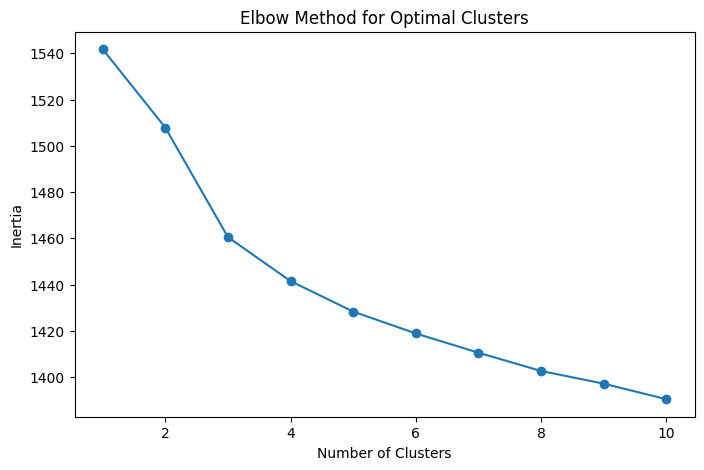

Enter the optimal number of clusters based on the elbow plot: 8
Texts have been clustered and saved to output_with_clusters.xlsx


In [13]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Path to the Excel file
output_file = "output_with_clusters.xlsx"  # File to save the results

# Ensure there is a column named "Text of Speech"
if "Text of Speech" not in df.columns:
    raise ValueError("The Excel sheet must contain a 'Text of Speech' column.")

# Extract the text data
texts = df["Text of Speech"].fillna("")  # Replace NaN with empty strings

# Step 1: Convert texts to TF-IDF features
tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)

# Step 2: Determine the optimal number of clusters using the elbow method
def find_optimal_clusters(data, max_k):
    inertias = []
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(data)
        inertias.append(kmeans.inertia_)
    return inertias

# Calculate inertias for 1 to 10 clusters
inertias = find_optimal_clusters(tfidf_matrix, 10)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertias, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Step 3: Perform K-means clustering with an optimal number of clusters
optimal_clusters = int(input("Enter the optimal number of clusters based on the elbow plot: "))
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
clusters = kmeans.fit_predict(tfidf_matrix)

# Step 4: Add the cluster labels to the DataFrame
df["Cluster"] = clusters

# Save the updated DataFrame back to an Excel file
df.to_excel(output_file, index=False)

print(f"Texts have been clustered and saved to {output_file}")


In [14]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

def apply_lda(texts, n_topics=3, n_top_words=10):
    vectorizer = CountVectorizer(stop_words="english")
    term_matrix = vectorizer.fit_transform(texts)
    lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
    lda.fit(term_matrix)
    terms = vectorizer.get_feature_names_out()
    topics = []
    for idx, topic in enumerate(lda.components_):
        topics.append([terms[i] for i in topic.argsort()[:-n_top_words - 1:-1]])
    return topics

for cluster in range(optimal_clusters):
    cluster_texts = df[df["Cluster"] == cluster]["Text of Speech"]
    topics = apply_lda(cluster_texts, n_topics=3)
    print(f"Cluster {cluster} Topics: {topics}")


Cluster 0 Topics: [['farmers', 'country', 'people', 'gujarat', 'today', 'government', 'india', 'new', 'farmer', 'friends'], ['farmers', 'country', 'friends', 'today', 'government', 'india', 'agriculture', 'new', 'sector', 'crore'], ['farmers', 'government', 'country', 'sisters', 'brothers', 'people', 'today', 'friends', 'ji', 'rs']]
Cluster 1 Topics: [['india', 'world', 'today', 'friends', 'people', 'country', 'years', 'energy', 'indian', 'new'], ['india', 'country', 'today', 'friends', 'new', 'government', 'sector', 'world', 'years', 'people'], ['india', 'friends', 'technology', 'today', 'world', 'country', 'new', 'science', 'people', 'youth']]
Cluster 2 Topics: [['bharat', 'country', 'today', 'friends', 'world', 'people', 'new', 'years', 'government', 'time'], ['bharat', 'friends', 'today', 'world', 'government', 'new', 'country', 'years', 'global', 'sector'], ['bharat', 'today', 'country', 'people', 'development', 'friends', 'new', 'government', 'projects', 'ji']]
Cluster 3 Topics: 

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def get_top_keywords(tfidf_matrix, feature_names, top_n=10):
    sorted_indices = np.argsort(tfidf_matrix.sum(axis=0)).A1[::-1]
    return [feature_names[i] for i in sorted_indices[:top_n]]

for cluster in range(optimal_clusters):
    cluster_texts = df[df["Cluster"] == cluster]["Text of Speech"]
    tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
    tfidf_matrix = tfidf_vectorizer.fit_transform(cluster_texts)
    feature_names = tfidf_vectorizer.get_feature_names_out()
    top_keywords = get_top_keywords(tfidf_matrix, feature_names)
    print(f"Cluster {cluster} Top Keywords: {top_keywords}")


Cluster 0 Top Keywords: ['farmers', 'country', 'government', 'friends', 'today', 'india', 'gujarat', 'people', 'new', 'sisters']
Cluster 1 Top Keywords: ['india', 'country', 'friends', 'world', 'today', 'new', 'government', 'people', 'sector', 'years']
Cluster 2 Top Keywords: ['bharat', 'today', 'country', 'friends', 'world', 'new', 'government', 'people', 'years', 'development']
Cluster 3 Top Keywords: ['और', 'हम', 'कर', 'पर', 'एक', 'रह', 'रत', 'नह', 'इस', 'बह']
Cluster 4 Top Keywords: ['country', 'india', 'people', 'today', 'friends', 'ji', 'new', 'world', 'time', 'sir']
Cluster 5 Top Keywords: ['country', 'health', 'people', 'india', 'friends', 'corona', 'today', 'medical', 'government', 'world']
Cluster 6 Top Keywords: ['country', 'government', 'people', 'today', 'friends', 'india', 'new', 'sisters', 'years', 'development']
Cluster 7 Top Keywords: ['india', 'minister', 'prime', 'global', 'countries', 'brics', 'today', 'cooperation', 'friends', 'president']


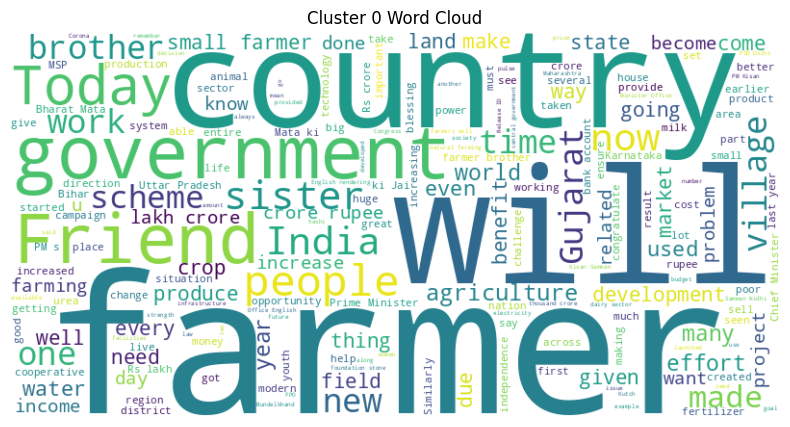

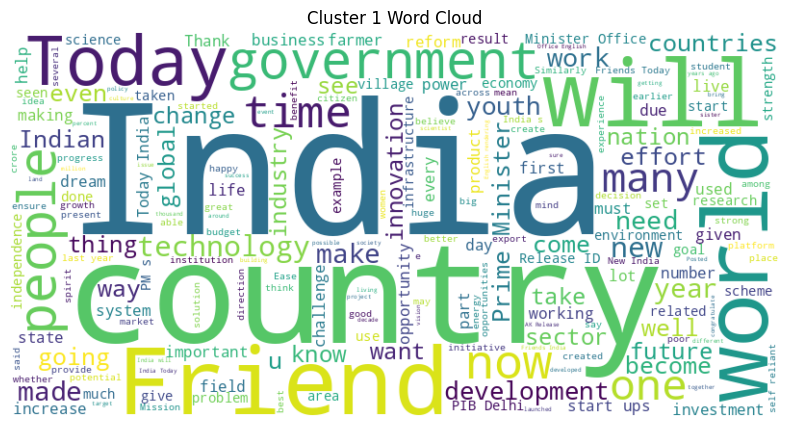

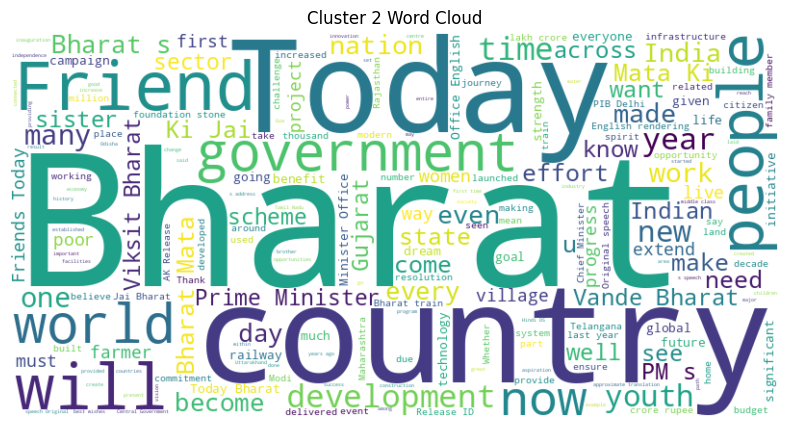

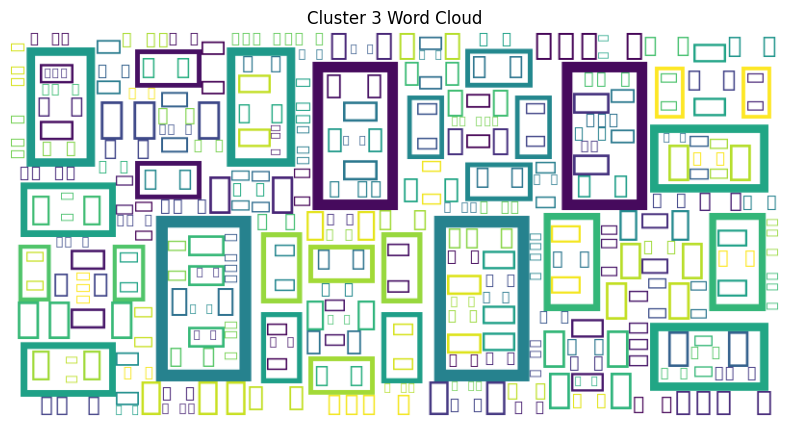

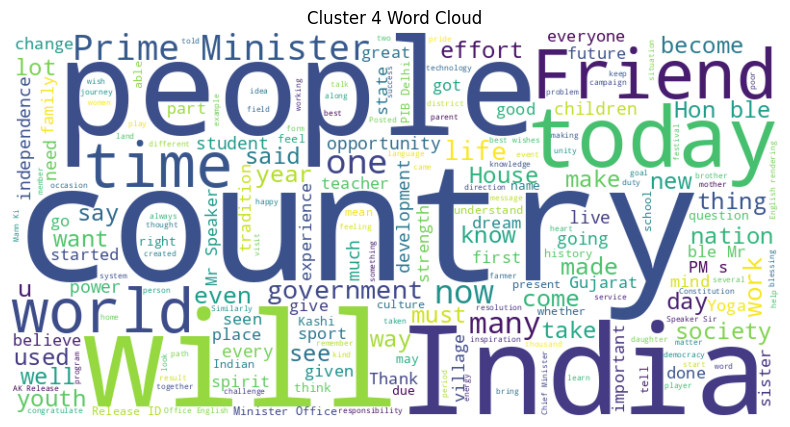

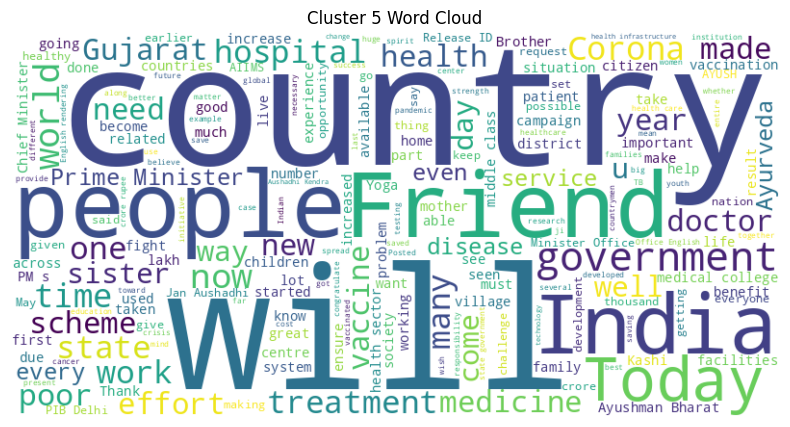

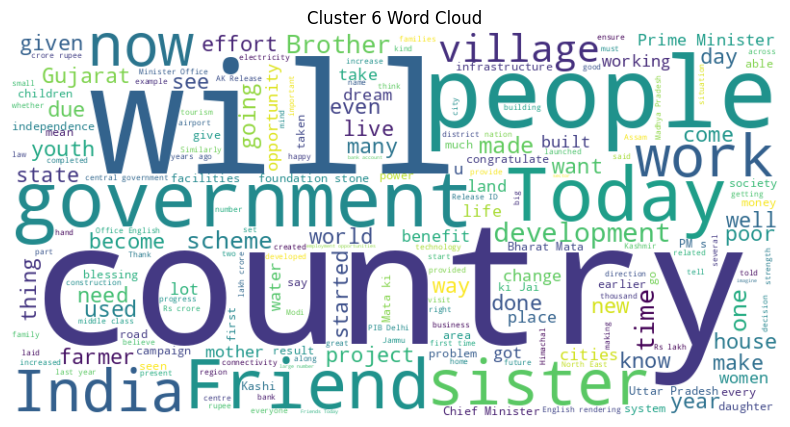

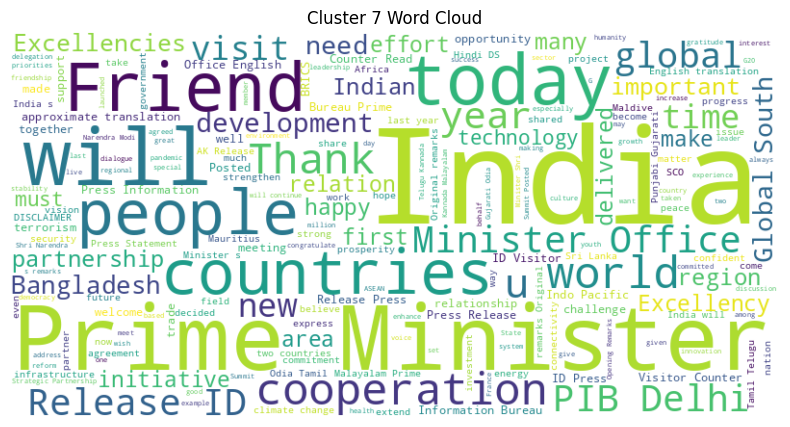

In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for cluster in range(optimal_clusters):
    cluster_texts = df[df["Cluster"] == cluster]["Text of Speech"]
    text_combined = " ".join(cluster_texts)
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text_combined)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Cluster {cluster} Word Cloud")
    plt.show()
